# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [1]:
# Replace this list with your selected tickers
tickers = ['JPM', 'GS', 'MS', 'BAC']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [2]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']
df.head()

/tmp/ipykernel_2648/2573897208.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']
[*********************100%***********************]  4 of 4 completed


Ticker,BAC,GS,JPM,MS
Date,,,,
2021-01-04,26.939926,236.367108,111.222633,59.289516
2021-01-05,26.913482,241.596574,110.656835,59.416695
2021-01-06,28.746493,254.740835,116.325464,63.486344
2021-01-07,29.627748,261.374822,121.074185,64.868323
2021-01-08,29.081371,258.185938,119.462087,63.876348


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [4]:
# Add code here 🔧
print(df.isnull().sum())
df = df.ffill()
print("Cleaned nulls:", df.isnull().sum().sum())

Ticker
BAC    0
GS     0
JPM    0
MS     0
dtype: int64
Cleaned nulls: 0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [5]:
# Add code here
returns = df.pct_change().dropna()
returns.head()

Ticker,BAC,GS,JPM,MS
Date,,,,
2021-01-05,-0.000982,0.022124,-0.005087,0.002145
2021-01-06,0.068108,0.054406,0.051227,0.068493
2021-01-07,0.030656,0.026042,0.040823,0.021768
2021-01-08,-0.018441,-0.012200,-0.013315,-0.015292
2021-01-11,0.003939,0.009306,0.013568,0.015397


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




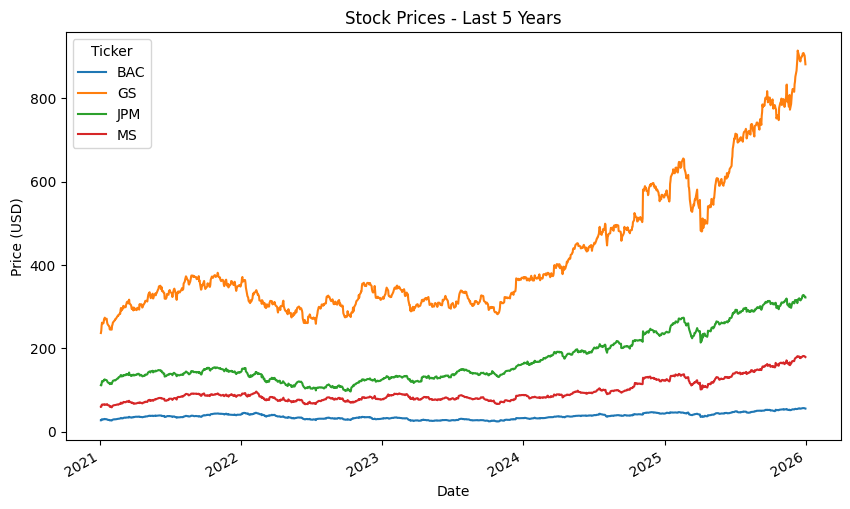

Daily Volatility:
 Ticker
BAC    0.016227
GS     0.016155
JPM    0.014214
MS     0.017033
dtype: float64


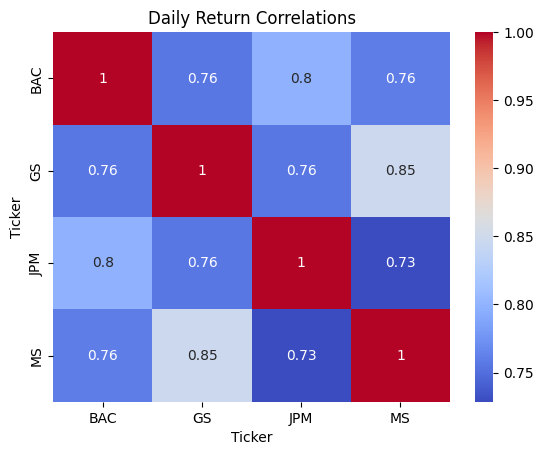

In [6]:
# Add code here
#Price Chart
df.plot(figsize=(10, 6), title="Stock Prices - Last 5 Years")
plt.ylabel("Price (USD)")
plt.show()

#Volatility (Standard Deviation)
volatility = returns.std()
print("Daily Volatility:\n", volatility)

#Correlation Matrix
corr_matrix = returns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Daily Return Correlations")
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:
To investment committee
from business analyst
subject: sector analysis and investment recommendation

Over the past five years, the financial sector has shown significant resilience through shifting interest rates. Analysis of daily high prices indicates a general upward trend, volatility correspondence with federal monetary policy shifts.
The data reveals a high degree of correlation between firms. Based on consistent price, recovery and correlation, I recommend maintaining a physician in this industry as the institutions are well positioned to benefit from the current economic conditions. I also suggest adding macro, economic indicators like treasure, yield, spreads into the next model.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [7]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] Converting notebook assignment_14_api.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 432307 bytes to assignment_14_api.html
